## Installazione

```bash
conda create -n stan_env -c conda-forge cmdstanpy
```

```bash
conda install -c conda-forge seaborn jupyter-book sphinx-exercise ghp-import arviz watermark -y
pip install sphinx-proof
```

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import arviz as az
import warnings
from cmdstanpy import cmdstan_path, CmdStanModel

/Users/corrado/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [55]:
stan_file = os.path.join('stan', 'bernoulli_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=0> N;
  array[N] int<lower=0, upper=1> y;
}
parameters {
  real<lower=0, upper=1> theta;
}
model {
  theta ~ beta(4, 6);
  y ~ bernoulli(theta);
}



In [43]:
model = CmdStanModel(stan_file=stan_file)
print(model)

CmdStanModel: name=bernoulli_model
	 stan_file=/Users/corrado/_repositories/ds4p/chapter_4/bernoulli_model.stan
	 exe_file=/Users/corrado/_repositories/ds4p/chapter_4/bernoulli_model
	 compiler_options=stanc_options={}, cpp_options={}


In [45]:
y = np.zeros(100, dtype=int)
y[:14] = 1

data = {
    "N" : 100,
    "y" : y
}

print(data)

{'N': 100, 'y': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


In [46]:
fit = model.sample(data=data)

07:12:51 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed


07:12:51 - cmdstanpy - INFO - CmdStan done processing.


In [47]:
print(fit.summary())

            Mean      MCSE    StdDev         5%        50%        95%  \
lp__  -49.544900  0.015862  0.709022 -50.993500 -49.272200 -49.023500   
theta   0.163315  0.000928  0.035790   0.110119   0.160702   0.227653   

         N_Eff  N_Eff/s    R_hat  
lp__   1998.09  54002.3  1.00065  
theta  1487.67  40207.3  1.00020  


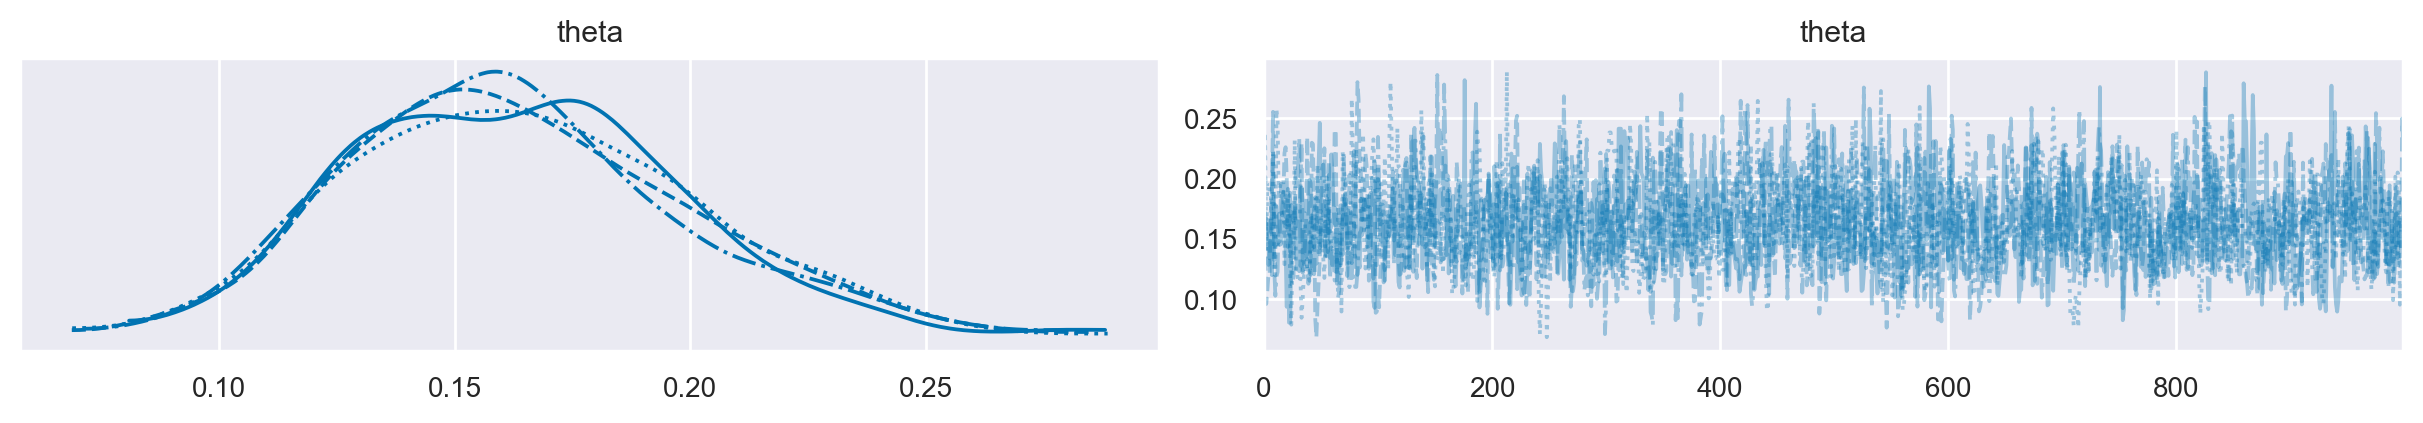

In [48]:
_ = az.plot_trace(fit)

In [49]:
az.summary(fit, hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.163,0.036,0.103,0.236,0.001,0.001,1493.0,2021.0,1.0


In [51]:
post = az.extract(fit)
post

<xarray.Dataset> Size: 128kB
Dimensions:  (sample: 4000)
Coordinates:
  * sample   (sample) object 32kB MultiIndex
  * chain    (sample) int64 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 32kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    theta    (sample) float64 32kB 0.1243 0.172 0.1605 ... 0.1398 0.139 0.1661
Attributes:
    created_at:                 2024-02-24T06:13:06.738614
    arviz_version:              0.17.0
    inference_library:          cmdstanpy
    inference_library_version:  1.2.1

In [52]:
post["theta"].shape

(4000,)

In [53]:
alpha_prior = 4
beta_prior = 6

Text(0, 0.5, 'Densità')

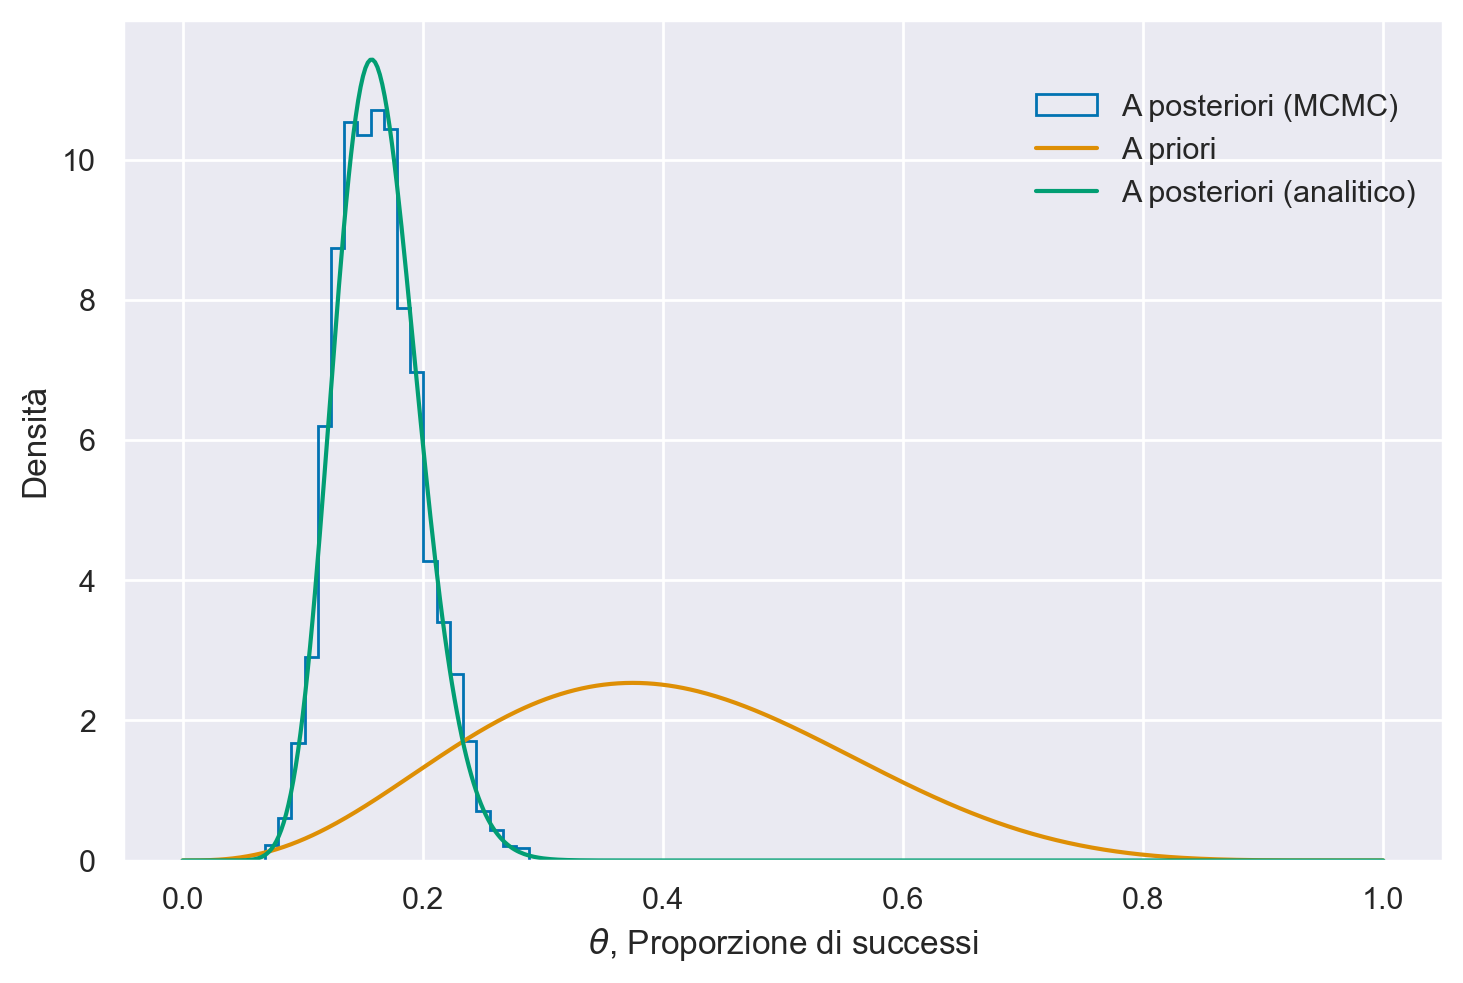

In [54]:
p_post = post["theta"]

# Posterior: Beta(alpha + y, beta + n - y)
alpha_post = alpha_prior + np.sum(data["y"])
beta_post = beta_prior + data["N"] - np.sum(data["y"])

plt.hist(
    p_post,
    bins=20,
    histtype="step",
    density=True,
    label="A posteriori (MCMC)",
    color="C0",
)

# Plot the analytic prior and posterior beta distributions
x = np.linspace(0, 1, 500)
plt.plot(
    x, stats.beta.pdf(x, alpha_prior, beta_prior), label="A priori", color="C1"
)
plt.plot(
    x,
    stats.beta.pdf(x, alpha_post, beta_post),
    label="A posteriori (analitico)",
    color="C2",
)

# Update the graph labels
plt.legend(title=" ", loc="best")
plt.xlabel("$\\theta$, Proporzione di successi")
plt.ylabel("Densità")